In [1]:
import qsample as qs
import time
import matplotlib.pyplot as plt

/Users/jhfontes/miniforge3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


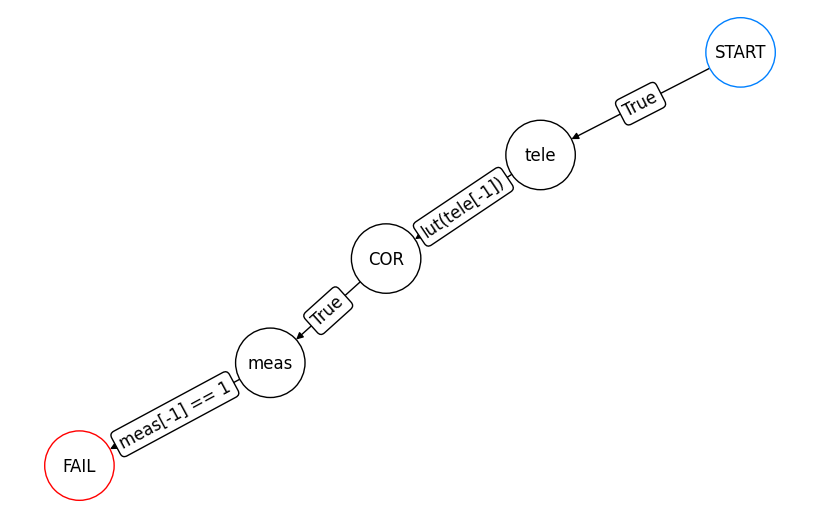

In [2]:
teleport = qs.Circuit([{"init": {0, 1, 2}},
                       {"H": {1}},
                       {"CNOT": {(1, 2)}},
                       {"CNOT": {(0, 1)}},
                       {"H": {0}},
                       {"measure": {0, 1}}])

meas = qs.Circuit([{"measure": {2}}], noisy=False)

def lut(syn):
    op = {0: 'I', 1: 'X', 2: 'Z', 3: 'Y'}[syn]
    return qs.Circuit([{op: {2}}], noisy=False)

tele_proto = qs.Protocol(check_functions={'lut': lut})
tele_proto.add_nodes_from(['tele', 'meas'], circuits=[teleport, meas])
tele_proto.add_edge('START', 'tele', check='True')
tele_proto.add_edge('tele', 'COR', check='lut(tele[-1])')
tele_proto.add_edge('COR', 'meas', check='True')
tele_proto.add_edge('meas', 'FAIL', check='meas[-1] == 1')

tele_proto.draw(figsize=(8,5), path = 'protocol_tele')

p=('1.00e-01',): 100%|██████████| 1000/1000 [00:00<00:00, 5782.06it/s]


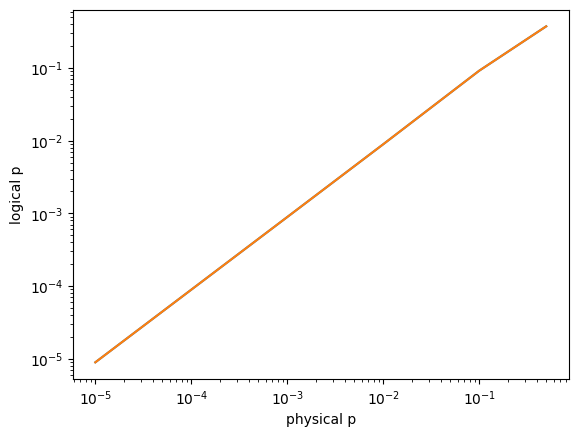

In [6]:
err_model = qs.noise.E1
q = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.5]
err_params = {'q': q}

ss_sam = qs.SubsetSampler(protocol=tele_proto, simulator=qs.StimSimulator,  p_max={'q': 0.1}, err_model=err_model, err_params=err_params, L=3)
ss_sam.run(1000)

v1 = ss_sam.stats()[0]
v2 = ss_sam.stats()[0]
plt.plot(q, v1)
plt.plot(q, v2)

plt.xscale('log')
plt.yscale('log')

plt.xlabel('physical p')
plt.ylabel('logical p')

plt.savefig('plog_tele')

p=('1.00e-02',): 100%|██████████| 10000/10000 [00:01<00:00, 6901.32it/s]


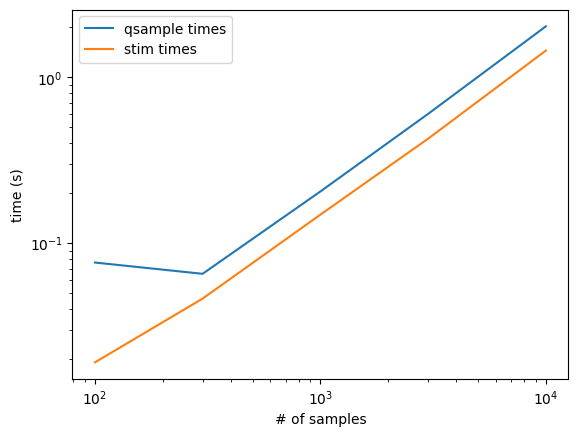

In [ ]:
qsample_times = []
stim_times = []

samples = [100, 300, 1000, 3000, 10000]

for s in samples:
    begin = time.time()
    ss_sam = qs.SubsetSampler(protocol=tele_proto, simulator=qs.StabilizerSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
    ss_sam.run(s)
    end = time.time()
    qsample_times.append(end-begin)

    begin = time.time()
    ss_sam = qs.SubsetSampler(protocol=tele_proto, simulator=qs.StimSimulator,  p_max={'q': 0.01}, err_model=err_model, err_params=err_params, L=3)
    ss_sam.run(s)
    end = time.time()
    stim_times.append(end-begin)

plt.plot(samples, qsample_times, label='qsample times')
plt.plot(samples, stim_times, label='stim times')
plt.xlabel('# of samples')
plt.ylabel('time (s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.savefig('times_tele')